In [95]:
import json
from azure.cognitiveservices.vision.computervision import ComputerVisionClient
from azure.cognitiveservices.vision.computervision.models import OperationStatusCodes
from azure.cognitiveservices.vision.computervision.models import VisualFeatureTypes
from msrest.authentication import CognitiveServicesCredentials
import time
import matplotlib.pyplot as plt
import cv2

In [9]:
from dotenv import load_dotenv
def authenticate():
    '''
    Authenticate
    Authenticates your credentials and creates a client.
    '''
    load_dotenv()
    VISION_KEY = "0iBXNB7UR8uDpjmzScO2TI5W0prTHAH86ISmGYXsA37UXGHmm7yhJQQJ99BCACi5YpzXJ3w3AAAFACOGopTW"
    VISION_ENDPOINT = "https://rares.cognitiveservices.azure.com/"
    subscription_key =VISION_KEY
    endpoint =VISION_ENDPOINT
    credentials = CognitiveServicesCredentials(subscription_key)
    computervision_client = ComputerVisionClient(endpoint, credentials)
    '''
    END - Authenticate
    '''
    return computervision_client

In [10]:
computervision_client = authenticate()

In [11]:
def get_image_ocr_result(image_path, language=None):
    img = open(image_path, "rb")
    read_response = computervision_client.read_in_stream(
        image=img,
        mode="Printed",
        raw=True,
        language=language
    )
    operation_id = read_response.headers['Operation-Location'].split('/')[-1]
    while True:
        read_result = computervision_client.get_read_result(operation_id)
        if read_result.status not in ['notStarted', 'running']:
            break
        time.sleep(1)
    return read_result

In [12]:
def get_text_of_file(image_path, language=None):
    read_result = get_image_ocr_result(image_path, language)
    # Print the detected text, line by line
    result = ""
    if read_result.status == OperationStatusCodes.succeeded:
        for text_result in read_result.analyze_result.read_results:
            for line in text_result.lines:
                result += line.text
                result += " "
    return result

In [101]:
print(get_text_of_file('test2.jpeg'))
print(get_text_of_file('test1.png'))

Lucces in resolvarea TEMELOR la LABORA toarele de Inteligenta Artificialà! 
Google Cloud Platform 


In [14]:
def get_location_of_text_file(image_path, language=None):
    read_result = get_image_ocr_result(image_path, language)
    locations = []
    if read_result.status == OperationStatusCodes.succeeded:
        for text_result in read_result.analyze_result.read_results:
            for line in text_result.lines:
                x1,y1,x2,y2,x3,y3,x4,y4=line.bounding_box
                locations.append([x1,y1,x3,y3])
    return locations

In [31]:
with open("informatii.json", "r") as file:
    data = json.load(file)

In [33]:
def cer_calculus(predictedtext, actualtext):
    predictedtext = predictedtext.lower()
    actualtext = actualtext.lower()
    predictedtext = re.sub(r'\W+', '', predictedtext)
    actualtext = re.sub(r'\W+', '', actualtext)

    lung_minima = min(len(actualtext), len(predictedtext))
    errors = abs(len(actualtext) - len(predictedtext))  # characters that are extra or missing
    for i in range(lung_minima):
        if predictedtext[i] != actualtext[i]:
            errors += 1
    cer = errors / len(actualtext)
    return cer

In [34]:
def perform_cer_on_all_images():
    cers = {}
    for file in data:
        image_path = file["image_path"]
        actual_text = file["actual_text"]
        predicted_text = get_text_of_file(image_path)
        cer = cer_calculus(predicted_text, actual_text)
        cers[image_path] = cer
    return cers
print(perform_cer_on_all_images())

{'test2.jpeg': 0.046875, 'test1.png': 0.0}


In [102]:
# Define the function to get all words from text
def get_all_words(text):
    words = re.findall(r'\w+', text)
    return words

# Example usage for the two images
image_paths = ['test2.jpeg', 'test1.png']

for image_path in image_paths:
    predicted_text = get_text_of_file(image_path)
    words = get_all_words(predicted_text)
    print(f"Words in {image_path}: {words}")

Words in test2.jpeg: ['Lucces', 'in', 'resolvarea', 'TEMELOR', 'la', 'LABORA', 'toarele', 'de', 'Inteligenta', 'Artificialà']
Words in test1.png: ['Google', 'Cloud', 'Platform']


In [40]:
def levenshtein_distance(s1, s2):
    # Inițializez matricea pentru memorarea distanțelor intermediare
    dp = [[i + j for j in range(len(s2) + 1)] for i in range(len(s1) + 1)]

    for i in range(1, len(s1) + 1):
        for j in range(1, len(s2) + 1):
            if s1[i - 1] == s2[j - 1]:
                dp[i][j] = dp[i - 1][j - 1]  # Caracterele sunt egale, nu se adaugă cost
            else:
                # Caracterele sunt diferite, se adaugă costul minim dintre inserție, ștergere și substituție
                dp[i][j] = min(dp[i][j - 1],      # Inserție
                               dp[i - 1][j],      # Ștergere
                               dp[i - 1][j - 1])  # Substitție
                dp[i][j] += 1  # Adaugă costul operației

    return dp[len(s1)][len(s2)]

In [42]:
def wer_word_error_rate(predicted_text, actual_text):
    predicted_words = get_all_words(predicted_text)
    actual_words = get_all_words(actual_text)

    n = len(predicted_words)
    m = len(actual_words)

    # dist Levenshtein
    dist = levenshtein_distance(predicted_text, actual_text)
    wer = dist / m
    return wer

In [43]:
def perform_wer_on_all_images():
    wers = {}
    for file in data:
        image_path = file["image_path"]
        actual_text = file["actual_text"]
        predicted_text = get_text_of_file(image_path)
        wer = wer_word_error_rate(predicted_text, actual_text)
        wers[image_path] = wer
    return wers
print(perform_wer_on_all_images())

{'test2.jpeg': 0.4, 'test1.png': 0.0}


In [114]:
def perform_levensthin_on_all_images():
    levs = {}
    for file in data:
        image_path = file["image_path"]
        actual_text = file["actual_text"]
        predicted_text = get_text_of_file(image_path)
        lev = levenshtein_distance(predicted_text, actual_text)
        levs[image_path] = lev
    return levs
print(perform_levensthin_on_all_images())

{'test2.jpeg': 4, 'test1.png': 0}


In [45]:
def jaro_winkler(s1, s2, p=0.1, max_prefix_len=4):
    """
    Calculează distanța Jaro-Winkler între două șiruri de caractere.

    :param s1: Primul șir de caractere.
    :param s2: Al doilea șir de caractere.
    :param p: Factorul de scalare pentru bonusul prefixului (default: 0.1).
    :param max_prefix_len: Lungimea maximă a prefixului comun pentru bonus (default: 4).
    :return: Similaritatea Jaro-Winkler între s1 și s2 (valoare între 0 și 1).
    """
    # Calculăm distanța Jaro
    jaro_dist = jaro_distance(s1, s2)

    # Calculăm lungimea prefixului comun (până la max_prefix_len)
    prefix_len = 0
    for i in range(min(len(s1), len(s2), max_prefix_len)):
        if s1[i] == s2[i]:
            prefix_len += 1
        else:
            break

    # Aplicăm bonusul Winkler
    winkler_bonus = prefix_len * p * (1 - jaro_dist)
    jaro_winkler_dist = jaro_dist + winkler_bonus

    return min(jaro_winkler_dist, 1.0)  # Asigurăm că valoarea nu depășește 1


def jaro_distance(s1, s2):
    """
    Calculează distanța Jaro între două șiruri de caractere.

    :param s1: Primul șir de caractere.
    :param s2: Al doilea șir de caractere.
    :return: Similaritatea Jaro între s1 și s2 (valoare între 0 și 1).
    """
    # Dacă șirurile sunt identice, distanța este 1
    if s1 == s2:
        return 1.0

    # Lungimile șirurilor
    len1, len2 = len(s1), len(s2)

    # Distanța maximă permisă pentru potrivirea caracterelor
    match_distance = (max(len1, len2) // 2) - 1

    # Listele pentru a ține evidența potrivirilor
    s1_matches = [False] * len1
    s2_matches = [False] * len2

    # Numărul de potriviri și transpoziții
    matches = 0
    transpositions = 0

    # Căutăm potriviri în s1 și s2
    for i in range(len1):
        start = max(0, i - match_distance)
        end = min(i + match_distance + 1, len2)

        for j in range(start, end):
            if not s2_matches[j] and s1[i] == s2[j]:
                s1_matches[i] = True
                s2_matches[j] = True
                matches += 1
                break

    # Dacă nu există potriviri, distanța este 0
    if matches == 0:
        return 0.0

    # Calculăm numărul de transpoziții
    k = 0
    for i in range(len1):
        if s1_matches[i]:
            while not s2_matches[k]:
                k += 1
            if s1[i] != s2[k]:
                transpositions += 1
            k += 1

    transpositions = transpositions // 2

    # Calculăm distanța Jaro
    jaro = (matches / len1 + matches / len2 + (matches - transpositions) / matches) / 3
    return jaro

In [47]:
def perform_jaro_winkler_on_all_images():
    jws = {}
    for file in data:
        image_path = file["image_path"]
        actual_text = file["actual_text"]
        predicted_text = get_text_of_file(image_path)
        jw = jaro_winkler(predicted_text, actual_text)
        jws[image_path] = jw
    return jws
print(perform_jaro_winkler_on_all_images())

{'test2.jpeg': 0.8470735524256652, 'test1.png': 1.0}


In [126]:
from PIL import Image, ImageDraw

def image_with_rectangle_surrounding_text(image_path, language=None):
    locations = get_location_of_text_file(image_path, language)
    image = Image.open(image_path)
    draw = ImageDraw.Draw(image)
    for location in locations:
        x1, y1, x3, y3 = location
        draw.rectangle([(x1, y1), (x3, y3)], outline="blue", width=3)
    image.show()

image_with_rectangle_surrounding_text('test1.png')
image_with_rectangle_surrounding_text('test2.jpeg')

In [118]:
def calculate_iou(box1, box2):
    """
    Calculate the Intersection over Union (IoU) of two bounding boxes.

    Parameters:
    box1, box2: Lists or tuples with coordinates [x1, y1, x2, y2]

    Returns:
    IoU: Intersection over Union value
    """
    x1_inter = max(box1[0], box2[0])
    y1_inter = max(box1[1], box2[1])
    x2_inter = min(box1[2], box2[2])
    y2_inter = min(box1[3], box2[3])

    inter_area = max(0, x2_inter - x1_inter) * max(0, y2_inter - y1_inter)

    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    union_area = box1_area + box2_area - inter_area

    iou = inter_area / union_area if union_area != 0 else 0
    return iou

def calculate_average_iou(predicted_locations, actual_locations):
    """
    Calculate the average IoU for all bounding boxes in an image.

    Parameters:
    predicted_locations: List of predicted bounding boxes
    actual_locations: List of actual bounding boxes

    Returns:
    average_iou: Average IoU value
    """
    total_iou = 0
    count = min(len(predicted_locations), len(actual_locations))

    for i in range(count):
        total_iou += calculate_iou(predicted_locations[i], actual_locations[i])

    average_iou = total_iou / count if count != 0 else 0
    return average_iou

In [119]:
def calculate_iou_for_each_line(predicted_locations, actual_locations):
    """
    Calculate the IoU for each pair of bounding boxes.

    Parameters:
    predicted_locations: List of predicted bounding boxes
    actual_locations: List of actual bounding boxes

    Returns:
    iou_list: List of IoU values for each pair of bounding boxes
    """
    iou_list = []
    count = min(len(predicted_locations), len(actual_locations))

    for i in range(count):
        iou = calculate_iou(predicted_locations[i], actual_locations[i])
        iou_list.append(iou)

    return iou_list

In [120]:
imagePrev=cv2.imread('test2.jpeg')

In [121]:
def quality_for_files():
    with open("informatii.json", "r") as file:
        data = json.load(file)

    quality_results = {}

    for file in data:
        image_path = file["image_path"]
        actual_locations = file["locations"]
        predicted_locations = get_location_of_text_file(image_path)
        iou_list = calculate_iou_for_each_line(predicted_locations, actual_locations)
        quality_results[image_path] = iou_list

    return quality_results

print(quality_for_files())

{'test2.jpeg': [0.7448415392929895, 0.8724405572127777, 0.8669754485975254, 0.8530608912680918], 'test1.png': [0.7453416149068323, 0.9405393457117595]}


In [122]:
def print_average_iou_for_files():
    with open("informatii.json", "r") as file:
        data = json.load(file)

    for file in data:
        image_path = file["image_path"]
        actual_locations = file["locations"]
        predicted_locations = get_location_of_text_file(image_path)
        average_iou = calculate_average_iou(predicted_locations, actual_locations)
print_average_iou_for_files()

In [83]:
import cv2
import numpy as np

def preprocess_image(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    # Binarizare
    _, binary_image = cv2.threshold(image, 128, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
    # Eliminarea zgomotului
    denoised_image = cv2.medianBlur(binary_image, 3)
    # Corectarea înclinării
    coords = np.column_stack(np.where(denoised_image > 0))
    angle = cv2.minAreaRect(coords)[-1]
    if angle < -45:
        angle = -(90 + angle)
    else:
        angle = -angle
    (h, w) = denoised_image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated_image = cv2.warpAffine(denoised_image, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)
    return rotated_image

In [84]:
from PIL import Image, ImageDraw, ImageFont

def image_with_iou_display(image_path, actual_locations, predicted_locations):
    image = Image.open(image_path)
    draw = ImageDraw.Draw(image)
    font = ImageFont.load_default()

    iou_list = calculate_iou_for_each_line(predicted_locations, actual_locations)

    for i, location in enumerate(predicted_locations):
        x1, y1, x3, y3 = location
        center_x = (x1 + x3) / 2
        center_y = (y1 + y3) / 2
        radius = max(x3 - x1, y3 - y1) / 2
        draw.ellipse([(center_x - radius, center_y - radius), (center_x + radius, center_y + radius)], outline="blue", width=3)
        draw.text((x1, y1), f"IoU: {iou_list[i]:.2f}", fill="red", font=font)

    image.show()

# Example usage
image_path = 'test1.png'
actual_locations = [[177,44,417,97],[234,112,350,151]]
predicted_locations = get_location_of_text_file(image_path)
image_with_iou_display(image_path, actual_locations, predicted_locations)

In [85]:
import pytesseract
from PIL import Image

def advanced_ocr(image_path):
    image = Image.open(image_path)
    text = pytesseract.image_to_string(image)
    return text

In [86]:
import re
from spellchecker import SpellChecker

def postprocess_text(text):
    spell = SpellChecker()
    words = re.findall(r'\w+', text)
    corrected_words = [spell.correction(word) for word in words if word is not None]
    corrected_words = [word for word in corrected_words if word is not None]  # Ensure no None values
    corrected_text = ' '.join(corrected_words)
    return corrected_text

# Example usage
image_path = 'test2.jpeg'
predicted_text = get_text_of_file(image_path)
corrected_text = postprocess_text(predicted_text)
print(f"Original Text: {predicted_text}")
print(f"Post-processed Text: {corrected_text}")

Original Text: Lucces in resolvarea TEMELOR la LABORA toarele de Inteligenta Artificialà! 
Post-processed Text: success in temblor la labor de intelligent artificial


In [88]:
import cv2

def deskew(image):
    # Check if the image is None
    if image is None:
        print("Error: Input image is None.")
        return None

    # Convert the image to grayscale if it has more than one channel
    if len(image.shape) > 2:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image

    # Threshold the image to get a binary image
    _, binary_image = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Find contours in the binary image
    contours, _ = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Check if any contours are found
    if not contours:
        print("No contours found.")
        return image  # Return the original image

    # Find the orientation angle of the rectangle enclosing the contours
    rect = cv2.minAreaRect(contours[0])
    angle = rect[-1]

    # Adjust the angle if necessary
    if angle < -45:
        angle = -(90 + angle)
    elif angle == 90:
        angle = 90
    else:
        angle = -angle

    # Rotate the image to deskew it
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)

    return rotated

In [90]:
def show_one_image(image_to_plot,cmap=None):
    plt.imshow(image_to_plot,cmap=cmap)
    plt.axis('off')
    plt.show()

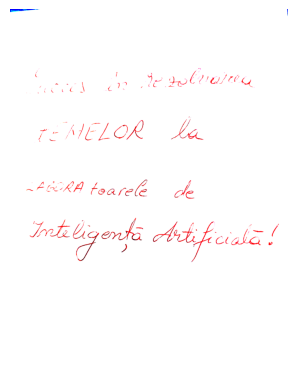

In [97]:
def binarization(image):
    _, binary_image = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)
    return binary_image
show_one_image(binarization(imagePrev))

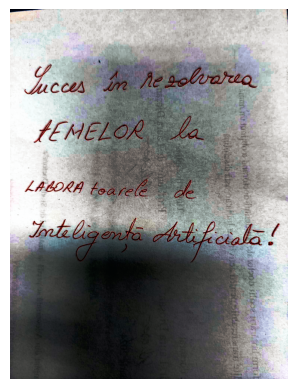

In [98]:
def enhance_contrast(image):
    if len(image.shape) == 2 or image.shape[2] == 1:  # Grayscale or single-channel image
        # Apply histogram equalization directly
        equalized = cv2.equalizeHist(image)
        enhanced_image = cv2.cvtColor(equalized, cv2.COLOR_GRAY2BGR)
    else:  # Color image
        # Separate color channels
        b, g, r = cv2.split(image)
        # Apply histogram equalization to each channel
        b_equalized = cv2.equalizeHist(b)
        g_equalized = cv2.equalizeHist(g)
        r_equalized = cv2.equalizeHist(r)
        # Merge equalized channels
        enhanced_image = cv2.merge([b_equalized, g_equalized, r_equalized])

    return enhanced_image
show_one_image(enhance_contrast(imagePrev))


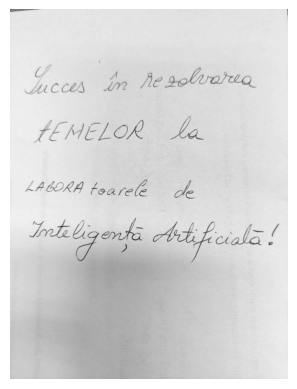

Text in normalized image: Lucces in resolvarea TEMELOR la LABORA toarele de Inteligenta Artificialà! 


In [106]:
import cv2

def normalization(image):
    image_norm = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    image_norm = cv2.normalize(image_norm, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)
    cv2.imwrite('normalized_image.png', image_norm)  # Save the normalized image
    return image_norm

# Normalize the image and save it
normalized_image = normalization(imagePrev)

# Display the normalized image
show_one_image(normalized_image, cmap='gray')

# Read the text from the normalized image
normalized_image_path = 'normalized_image.png'
predicted_text = get_text_of_file(normalized_image_path)
print(f"Text in normalized image: {predicted_text}")

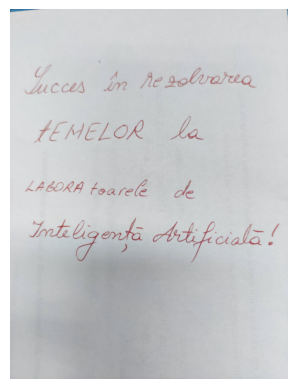

In [94]:
def noise_removal(image):
    blurred_image = cv2.GaussianBlur(image, (5, 5), 0)

    # emove small noise
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    opened_image = cv2.morphologyEx(blurred_image, cv2.MORPH_OPEN, kernel)
    # after it comes thresholding -binarizing
    return opened_image
show_one_image(noise_removal(imagePrev))

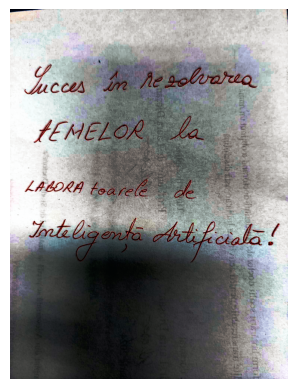

Text in enhanced image: Succes in resolvarea TEMELOR la LABORA toarele de Inteligenta Artificialà! 


In [109]:
import cv2

def enhance_contrast(image):
    if len(image.shape) == 2 or image.shape[2] == 1:  # Grayscale or single-channel image
        equalized = cv2.equalizeHist(image)
        enhanced_image = cv2.cvtColor(equalized, cv2.COLOR_GRAY2BGR)
    else:  # Color image
        b, g, r = cv2.split(image)
        b_equalized = cv2.equalizeHist(b)
        g_equalized = cv2.equalizeHist(g)
        r_equalized = cv2.equalizeHist(r)
        enhanced_image = cv2.merge([b_equalized, g_equalized, r_equalized])
    return enhanced_image

# Enhance contrast and display the image
enhanced_image = enhance_contrast(imagePrev)
show_one_image(enhanced_image)

# Read the text from the enhanced image
cv2.imwrite('enhanced_image.png', enhanced_image)
predicted_text = get_text_of_file('enhanced_image.png')
print(f"Text in enhanced image: {predicted_text}")